In [9]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/Autism.csv")

# Show first 5 rows
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2,'18 and more',?,NO


In [10]:
# Dataset dimensions
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset info
print("\nDataset Info:")
df.info()

Shape of dataset: (704, 21)

Columns:
Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   A1_Score         704 non-null    int64
 1   A2_Score         704 non-null    int64
 2   A3_Score         704 non-null    int64
 3   A4_Score         704 non-null    int64
 4   A5_Score         704 non-null    int64
 5   A6_Score         704 non-null    int64
 6   A7_Score         704 non-null    int64
 7   A8_Score         704 non-null    int64
 8   A9_Score         704 non-null    int64
 9   A10_Score        704 non-null    int64
 10  age              

In [11]:
# Missing values
missing_values = df.isnull().sum()

print(missing_values)

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64


In [12]:
# Target variable distribution
df['Class/ASD'].value_counts()

Class/ASD
NO     515
YES    189
Name: count, dtype: int64

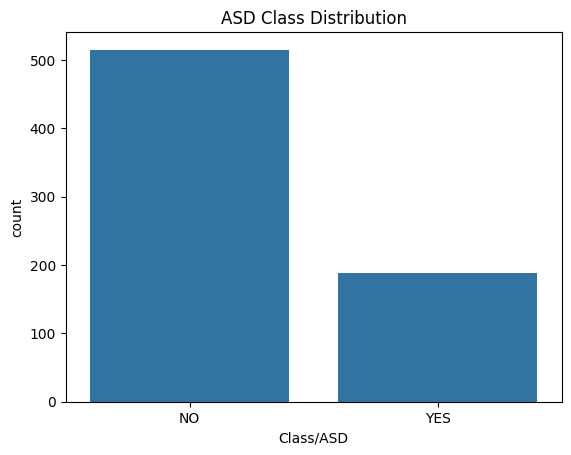

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count plot
sns.countplot(x='Class/ASD', data=df)

plt.title("ASD Class Distribution")
plt.show()

In [14]:
# Behavioral score columns
behavior_cols = [
    'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
    'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score'
]

# Mean scores
behavior_means = df[behavior_cols].mean()

print(behavior_means)

A1_Score     0.721591
A2_Score     0.453125
A3_Score     0.457386
A4_Score     0.495739
A5_Score     0.498580
A6_Score     0.284091
A7_Score     0.417614
A8_Score     0.649148
A9_Score     0.323864
A10_Score    0.573864
dtype: float64


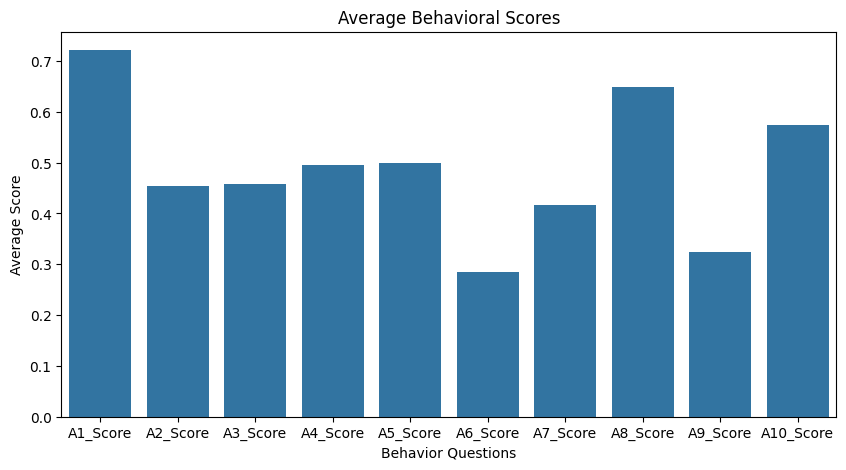

In [15]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=behavior_means.index,
    y=behavior_means.values
)

plt.title("Average Behavioral Scores")
plt.xlabel("Behavior Questions")
plt.ylabel("Average Score")

plt.show()

In [16]:
# Create total behavior score
df['behavior_total_score'] = df[behavior_cols].sum(axis=1)

# Preview
df[['behavior_total_score', 'Class/ASD']].head()

,behavior_total_score,Class/ASD
0,6,NO
1,5,NO
2,8,YES
3,6,NO
4,2,NO


In [17]:
# Summary statistics
df['behavior_total_score'].describe()

count    704.000000
mean       4.875000
std        2.501493
min        0.000000
25%        3.000000
50%        4.000000
75%        7.000000
max       10.000000
Name: behavior_total_score, dtype: float64

In [18]:
# Compare average scores by ASD class
df.groupby('Class/ASD')['behavior_total_score'].mean()

Class/ASD
NO     3.631068
YES    8.264550
Name: behavior_total_score, dtype: float64

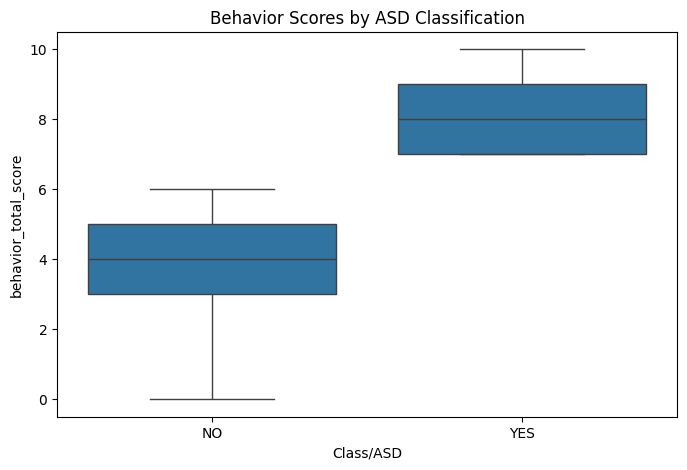

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Class/ASD',
    y='behavior_total_score',
    data=df
)

plt.title("Behavior Scores by ASD Classification")

plt.show()

In [20]:
# Gender distribution
df['gender'].value_counts()

gender
m    367
f    337
Name: count, dtype: int64

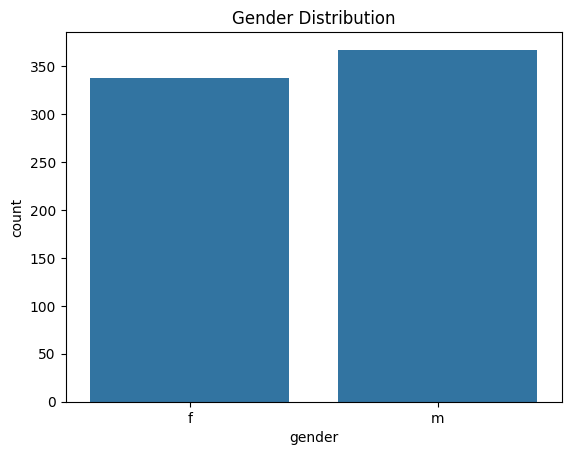

In [21]:
sns.countplot(x='gender', data=df)

plt.title("Gender Distribution")

plt.show()

In [22]:
# Gender vs ASD
gender_asd = pd.crosstab(df['gender'], df['Class/ASD'])

print(gender_asd)

Class/ASD   NO  YES
gender             
f          234  103
m          281   86


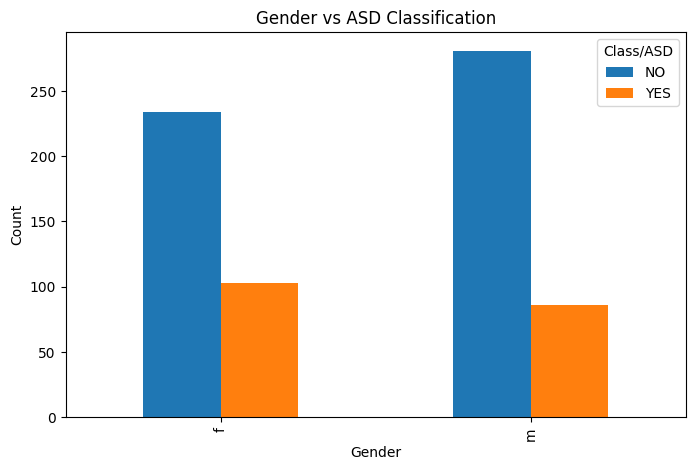

In [23]:
gender_asd.plot(kind='bar', figsize=(8,5))

plt.title("Gender vs ASD Classification")

plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

In [24]:
# Percentage distribution
gender_percent = pd.crosstab(
    df['gender'],
    df['Class/ASD'],
    normalize='index'
) * 100

print(gender_percent)

Class/ASD         NO        YES
gender                         
f          69.436202  30.563798
m          76.566757  23.433243


In [25]:
# Ethnicity counts
df['ethnicity'].value_counts()

ethnicity
White-European       233
Asian                123
?                     95
'Middle Eastern '     92
Black                 43
'South Asian'         36
Others                30
Latino                20
Hispanic              13
Pasifika              12
Turkish                6
others                 1
Name: count, dtype: int64

In [26]:
# Clean ethnicity column
df['ethnicity'] = df['ethnicity'].replace({
    'others': 'Others',
    '?': 'Unknown'
})

# Check updated values
df['ethnicity'].value_counts()

ethnicity
White-European       233
Asian                123
Unknown               95
'Middle Eastern '     92
Black                 43
'South Asian'         36
Others                31
Latino                20
Hispanic              13
Pasifika              12
Turkish                6
Name: count, dtype: int64

In [27]:
# Remove quotes and extra spaces
df['ethnicity'] = (
    df['ethnicity']
    .str.replace("'", "", regex=False)
    .str.strip()
)

# Check cleaned values
df['ethnicity'].value_counts()

ethnicity
White-European    233
Asian             123
Unknown            95
Middle Eastern     92
Black              43
South Asian        36
Others             31
Latino             20
Hispanic           13
Pasifika           12
Turkish             6
Name: count, dtype: int64

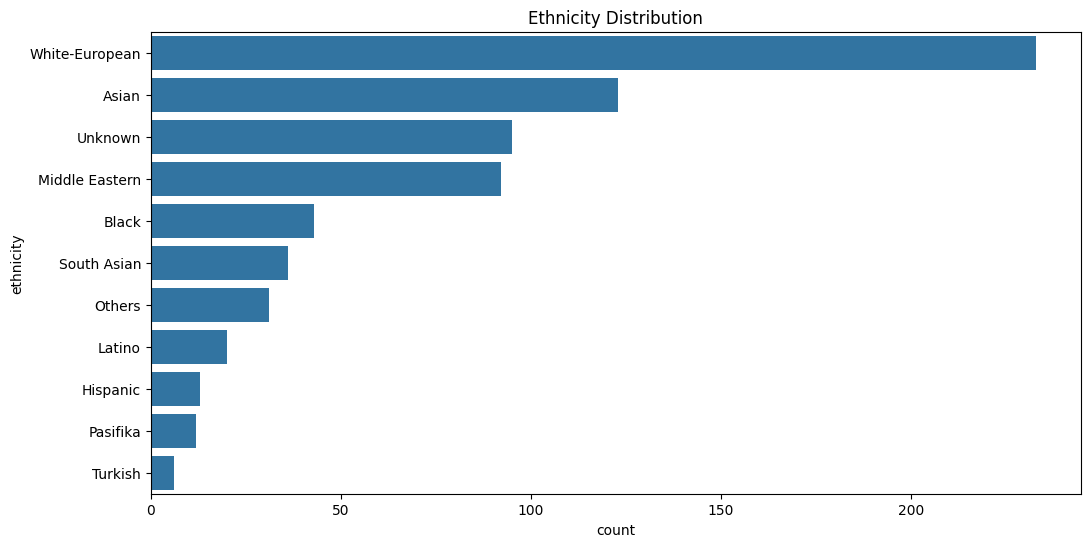

In [28]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='ethnicity',
    data=df,
    order=df['ethnicity'].value_counts().index
)

plt.title("Ethnicity Distribution")

plt.show()

In [29]:
ethnicity_asd = pd.crosstab(
    df['ethnicity'],
    df['Class/ASD']
)

print(ethnicity_asd)

Class/ASD        NO  YES
ethnicity               
Asian           107   16
Black            25   18
Hispanic          8    5
Latino           10   10
Middle Eastern   84    8
Others           22    9
Pasifika         11    1
South Asian      33    3
Turkish           5    1
Unknown          86    9
White-European  124  109


In [30]:
ethnicity_percent = pd.crosstab(
    df['ethnicity'],
    df['Class/ASD'],
    normalize='index'
) * 100

print(ethnicity_percent)

Class/ASD              NO        YES
ethnicity                           
Asian           86.991870  13.008130
Black           58.139535  41.860465
Hispanic        61.538462  38.461538
Latino          50.000000  50.000000
Middle Eastern  91.304348   8.695652
Others          70.967742  29.032258
Pasifika        91.666667   8.333333
South Asian     91.666667   8.333333
Turkish         83.333333  16.666667
Unknown         90.526316   9.473684
White-European  53.218884  46.781116


In [31]:
# Correlation matrix for behavioral scores
correlation_matrix = df[behavior_cols].corr()

correlation_matrix

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score
A1_Score,1.000000,0.011539,0.074096,0.127814,0.169369,0.110199,0.217538,0.147640,0.145452,0.118413
A2_Score,0.011539,1.000000,0.223921,0.158998,0.153821,0.185864,-0.041768,0.035408,0.205421,0.068883
A3_Score,0.074096,0.223921,1.000000,0.412722,0.264927,0.268846,0.078216,0.017771,0.315113,0.168454
A4_Score,0.127814,0.158998,0.412722,1.000000,0.306806,0.295152,0.151236,0.008617,0.327673,0.210968
A5_Score,0.169369,0.153821,0.264927,0.306806,1.000000,0.392354,0.238589,0.102086,0.396582,0.267561
A6_Score,0.110199,0.185864,0.268846,0.295152,0.392354,1.000000,0.175489,0.100123,0.479422,0.294435
A7_Score,0.217538,-0.041768,0.078216,0.151236,0.238589,0.175489,1.000000,0.085403,0.189480,0.252107
A8_Score,0.147640,0.035408,0.017771,0.008617,0.102086,0.100123,0.085403,1.000000,0.101733,0.100782
A9_Score,0.145452,0.205421,0.315113,0.327673,0.396582,0.479422,0.189480,0.101733,1.000000,0.283340
A10_Score,0.118413,0.068883,0.168454,0.210968,0.267561,0.294435,0.252107,0.100782,0.283340,1.000000


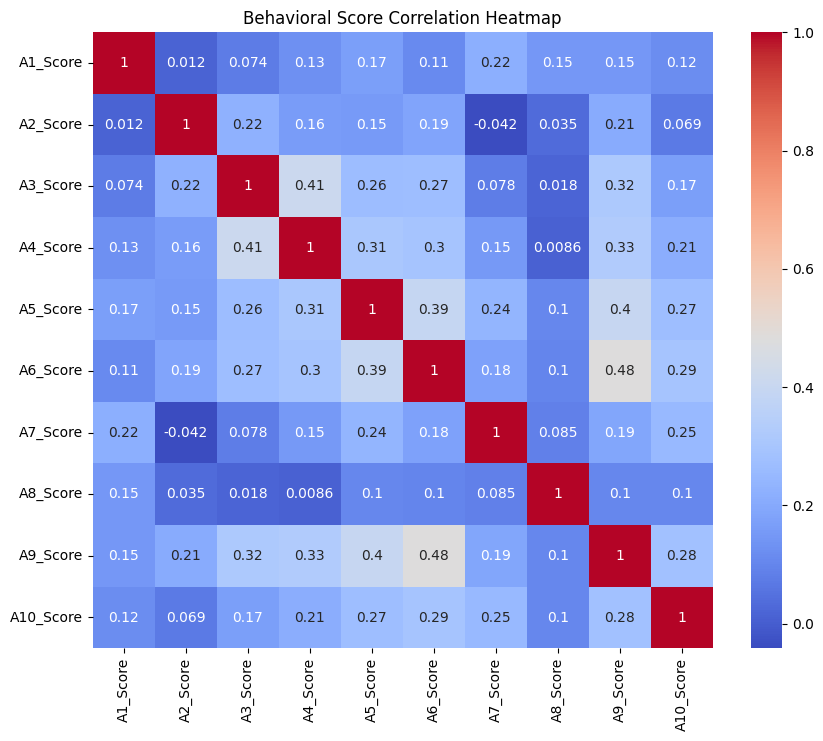

In [32]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Behavioral Score Correlation Heatmap")

plt.show()

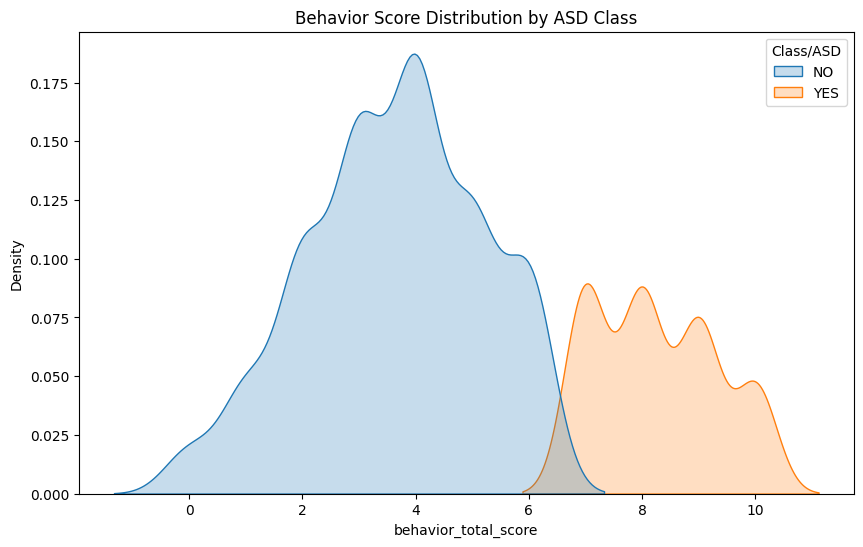

In [33]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x='behavior_total_score',
    hue='Class/ASD',
    fill=True
)

plt.title("Behavior Score Distribution by ASD Class")

plt.show()

In [34]:
# Convert target to numeric
df['Class/ASD'] = df['Class/ASD'].map({
    'NO': 0,
    'YES': 1
})

# Verify
df['Class/ASD'].head()

0    0
1    0
2    1
3    0
4    0
Name: Class/ASD, dtype: int64

In [35]:
# Features
X = df[behavior_cols]

# Target
y = df['Class/ASD']

print(X.shape)
print(y.shape)

(704, 10)
(704,)


In [36]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (563, 10)
X_test: (141, 10)
y_train: (563,)
y_test: (141,)


In [37]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [38]:
# Predictions
y_pred = model.predict(X_test)

# Show predictions
print(y_pred[:10])

[1 0 1 0 0 0 0 0 0 1]


In [39]:
from sklearn.metrics import accuracy_score

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [40]:
from sklearn.metrics import classification_report

# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        36

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141



In [41]:
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[105   0]
 [  0  36]]


In [42]:
# Feature importance from logistic regression
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Sort by importance
importance_df = importance_df.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance_df)

     Feature  Coefficient
8   A9_Score     2.312218
0   A1_Score     2.293818
5   A6_Score     2.204447
4   A5_Score     2.188538
7   A8_Score     2.075602
6   A7_Score     2.074616
3   A4_Score     2.032539
2   A3_Score     2.002195
1   A2_Score     1.911147
9  A10_Score     1.787902


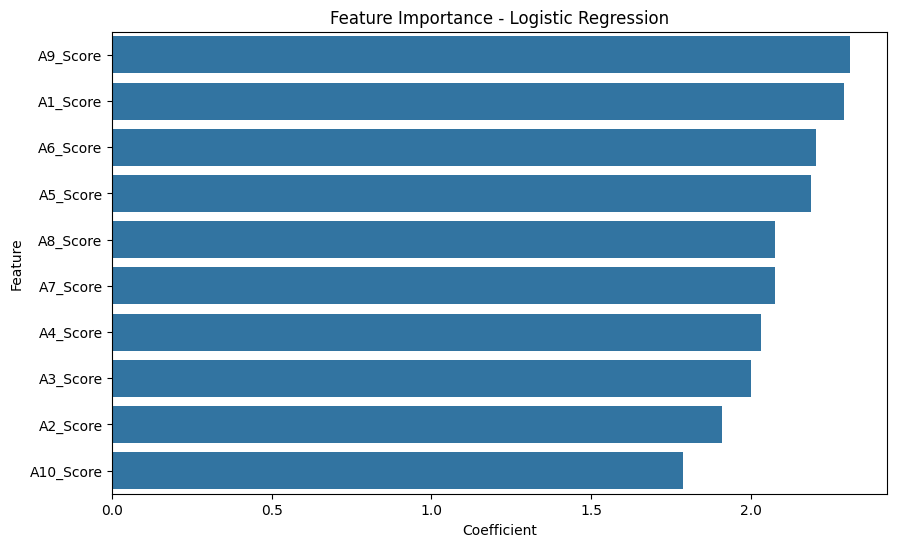

In [43]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x='Coefficient',
    y='Feature'
)

plt.title("Feature Importance - Logistic Regression")

plt.show()

In [44]:
from sklearn.preprocessing import StandardScaler

# Scale behavioral features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(704, 10)


In [45]:
from sklearn.cluster import KMeans

In [46]:
inertia = []

# Test different cluster sizes
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

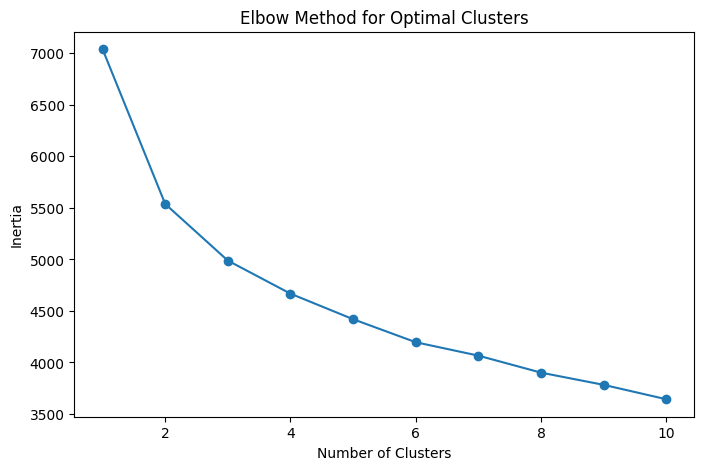

In [47]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [48]:
# Final KMeans model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Fit model
kmeans.fit(X_scaled)

# Assign clusters
df['cluster'] = kmeans.labels_

# Preview
df[['behavior_total_score', 'cluster']].head()

,behavior_total_score,cluster
0,6,0
1,5,0
2,8,2
3,6,0
4,2,0


In [49]:
# Cluster sizes
df['cluster'].value_counts()

cluster
0    320
2    216
1    168
Name: count, dtype: int64

In [50]:
# Average behavior score by cluster
df.groupby('cluster')['behavior_total_score'].mean()

cluster
0    3.931250
1    2.708333
2    7.958333
Name: behavior_total_score, dtype: float64

In [52]:
from sklearn.decomposition import PCA

# PCA transformation
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'cluster': df['cluster']
})

pca_df.head()

,PCA1,PCA2,cluster
0,0.130911,-0.160899,0
1,-0.398687,-0.015858,0
2,1.795146,0.934637,2
3,0.089902,0.981451,0
4,-2.167170,0.849716,0


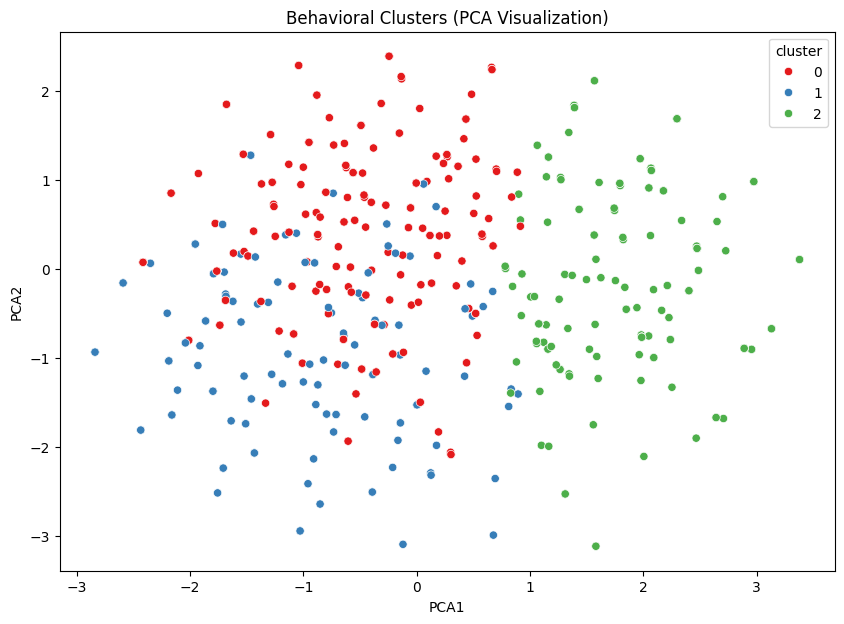

In [53]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='cluster',
    palette='Set1'
)

plt.title("Behavioral Clusters (PCA Visualization)")

plt.show()